# **Mascaras y Hitmaps de SO**

Aqui mostrare los hitmaps y mascaras encontrados de SO, para ello es necesario descargar documentos desde la NERSC.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mapsims 
import healpy as hp
import pysm3 as pysm

Lo primero dentro de mapsims hay que buscar el docuemnto que contiene la informacion instrumental de los tubos ST0-ST3 para SAT y LT0-LT6 para LAT. Esto fue idea de ChatGPT no tenia idea que se podria hacer esto jajjsaajs bendito

- veamos un ejemplo para el tubo ST0 para SAT

In [8]:
from mapsims import noise
import mapsims
import healpy as hp

from pathlib import Path

data_dir = Path(mapsims.__file__).parent / "data"

instrument_file = None

for f in data_dir.rglob("*.tbl"):
    try:
        if "ST0" in f.read_text(errors="ignore"):
            instrument_file = f
            break
    except Exception:
        pass

print("Usando:")
print(instrument_file)

print(mapsims.__version__)


Usando:
/home/jorge/miniconda3/envs/mapsims/lib/python3.10/site-packages/mapsims/data/simonsobs_instrument_parameters_2020.06/simonsobs_instrument_parameters_2020.06.tbl
2.6.0


# **Visualizar los hitmaps**

Estos hitmaps fueron realizados con archivo python hitmaps_mapsims que esta dentro de script_main.

En delensing son utilizados al construir $\hat E^{WF}_{\ell, m}$, donde segun el paper de 2022 asumen una matriz de covarianza diagonal en el espacio real. Aunque en las actuales simulaciones se tiene ruido correlacionado entre distintos pixeles debido al ruido atmosferico. Los elementos diagonales son tomados de la forma $ \sigma^2_{t,\nu}/H_t(\hat n) $ donde $ H_t(\hat n) $ corresponde al hit count normalizado y $ \sigma^2_{t,\nu} $ es el ruido blanco de cada mapa $t,\nu$. Se asume tambien un mismo hit count para todas las frecuencias de un telescopio.

**Necesario correr con enviroment mapsims**

Retrieve data for ST0_UHF1_01_of_20.nominal_telescope_all_time_all_hmap.fits.gz (if not cached already)
Retrieve data for ST0_UHF2_01_of_20.nominal_telescope_all_time_all_hmap.fits.gz (if not cached already)
Retrieve data for ST0_UHF1_01_of_20.nominal_telescope_all_time_all_hmap.fits.gz (if not cached already)
Retrieve data for ST0_UHF2_01_of_20.nominal_telescope_all_time_all_hmap.fits.gz (if not cached already)


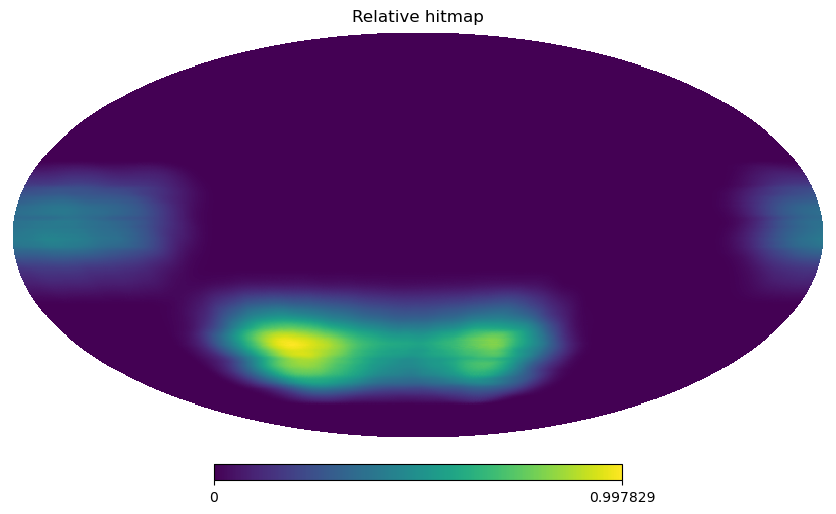

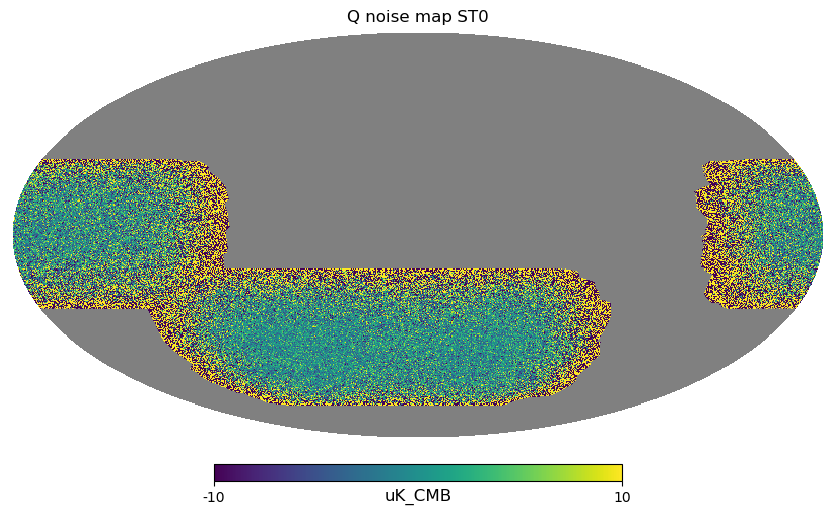

In [10]:
from mapsims import noise
import healpy as hp
noise_sim = noise.SONoiseSimulator(
    nside=2048,
    sensitivity_mode="goal",
    instrument_parameters=str(instrument_file)
)
hp.mollview(noise_sim.get_hitmaps("ST0")[0][0], title="Relative hitmap")
noise_maps = noise_sim.simulate(tube="ST0")
hp.mollview(noise_maps[0][0][1], min=-10, max=10, unit="uK_CMB", title="Q noise map ST0")

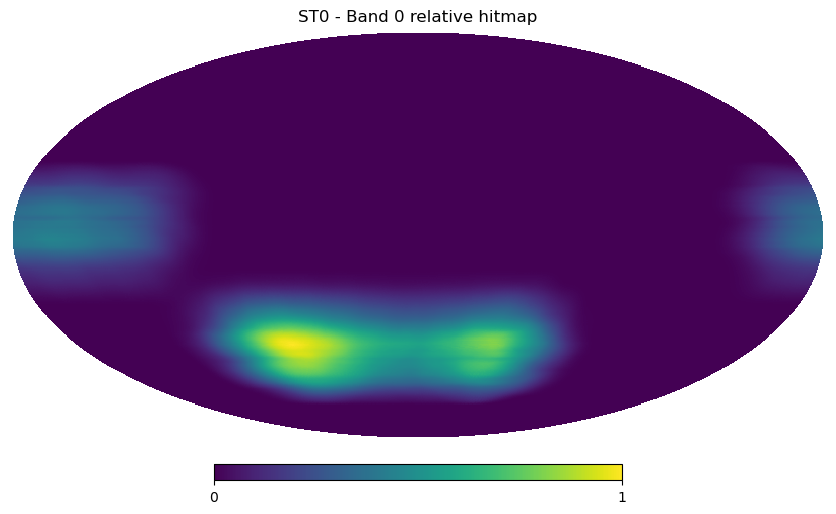

In [ ]:
import os
os.chdir("/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc")

##SAT

hitmaps = hp.read_map(
    "SO_maps/Hitmaps/SAT/ST0_hitmap_nside2048.fits",
    field=None
)

hp.mollview(
    hitmaps[0],
    title="ST0 - Band 0 relative hitmap",
    min=0,
    max=1
)

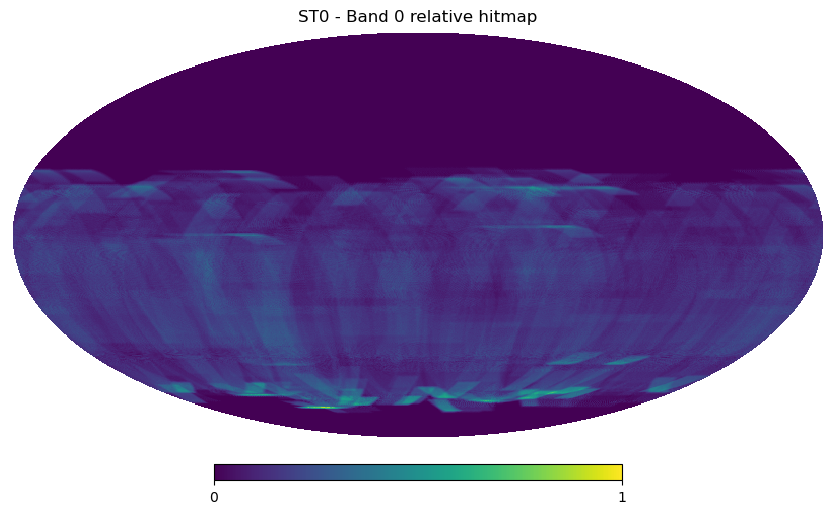

In [11]:
import os
os.chdir("/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc")

##LAT
hitmaps = hp.read_map(
    "SO_maps/Hitmaps/LAT/LT6_hitmap_nside2048.fits",
    field=None
)

hp.mollview(
    hitmaps[0],
    title="ST0 - Band 0 relative hitmap",
    min=0,
    max=1
)

## **SO Mask** 

Basandonos en [check_cmb_mask dado por SO](https://github.com/simonsobs/delensing/blob/master/check_cmb_mask.ipynb) usaremos las mascaras que son mostradas en ese documento para nuestro pipeline.

Para ello fue necesario descargar dos documentos por NERSC, en la dirección ``/global/cfs/cdirs/sobs/delensing/mask``:

- mask_apodized.fits
- simonsobs_noise_mask_x_mask_V3_bool.fits

Usaremos el enviroment de cmblensplus


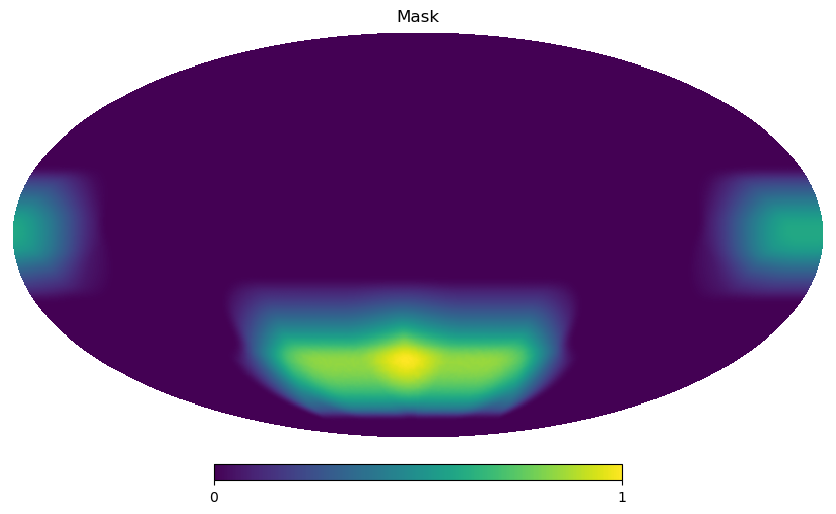

In [20]:
import os
os.chdir("/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc")

##LAT
mask_apo = hp.read_map(
    "SO_maps/Mask_SO/mask_apodized.fits",
    field=None
)

hp.mollview(
    mask_apo,
    title="Mask",
    min=0,
    max=1
)

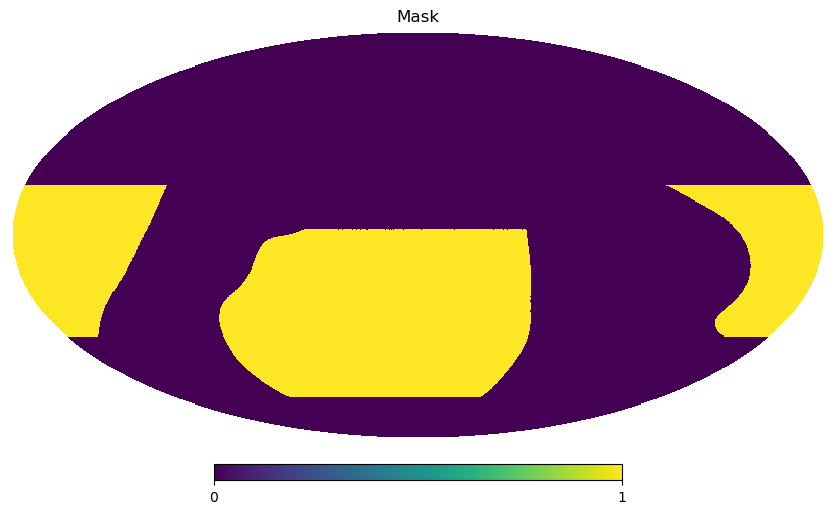

In [21]:
import os
os.chdir("/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc")

##LAT
mask_apo = hp.read_map(
    "SO_maps/Mask_SO/simonsobs_noise_mask_x_mask_V3_bool.fits",
    field=None
)

hp.mollview(
    mask_apo,
    title="Mask",
    min=0,
    max=1
)

In [1]:
import healpy as hp, numpy as np, curvedsky
from matplotlib.pyplot import *

In [2]:
def apodmask(W,t,ascale,nside,output=False):
    """ 
    Esta funcion se encarga de apodizar los mapas, de forma equivalente al documento de SO.

    Parameter:
    - W: 
    - t: telescope "LAT" or "SAT"
    - ascale: grado de apodizacion
    - output: True si se quiere guardar 
    """
    tag_name = t + "_binary.fits"
    fmask = "SO_maps/Mask_SO/" + tag_name

    #si es binaria
    if ascale==0: fname = fmask

    #si esta apodizada
    if ascale!=0: fname = fmask.replace('binary','a'+str(ascale)+'deg')

    amask = curvedsky.utils.apodize(nside,W,ascale)
    if output: hp.fitsfunc.write_map(fname,amask,overwrite=True)
    print(np.mean(amask/(amask+1e-30)))
    print(np.mean(amask**1))
    print(np.mean(amask**2))
    print(np.mean(amask**3))
    print(np.mean(amask**4))
    hp.mollview(amask)

import os
os.chdir("/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc")


ascale = 5.
dwin = 'SO_maps/Mask_SO/'
fmaskla = dwin + 'simonsobs_noise_mask_x_mask_V3_bool.fits'
fmasksa = dwin + 'mask_apodized.fits'

### **LAT mask**

/tmp/ipykernel_17700/1410806045.py:1: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  Wla = hp.fitsfunc.read_map(fmaskla,verbose=False)


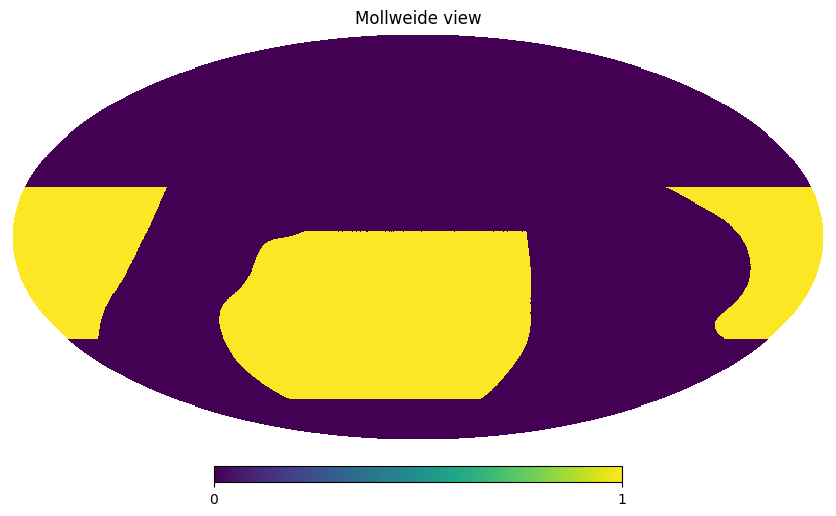

In [3]:
Wla = hp.fitsfunc.read_map(fmaskla,verbose=False)
wla = hp.pixelfunc.ud_grade(Wla,2048)
hp.mollview(Wla)

setting the output map dtype to [dtype('float64')]


 converting RING -> NESTED
 compute distance
 converting NESTED - > RING
 compute apodized window
0.2910047173500061
0.25404106812564026
0.24660663194819224
0.24293087378051578
0.24061642729389157


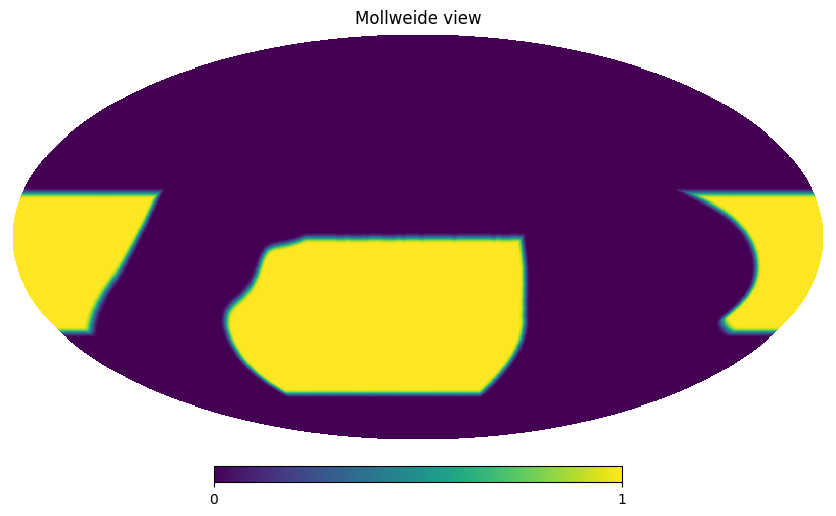

In [4]:
apodmask(wla,'LAT',ascale,2048, output=True)

### **SAT mask**

/tmp/ipykernel_17700/2762837788.py:1: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  wsa = hp.ud_grade(hp.fitsfunc.read_map(fmasksa,verbose=False),512)


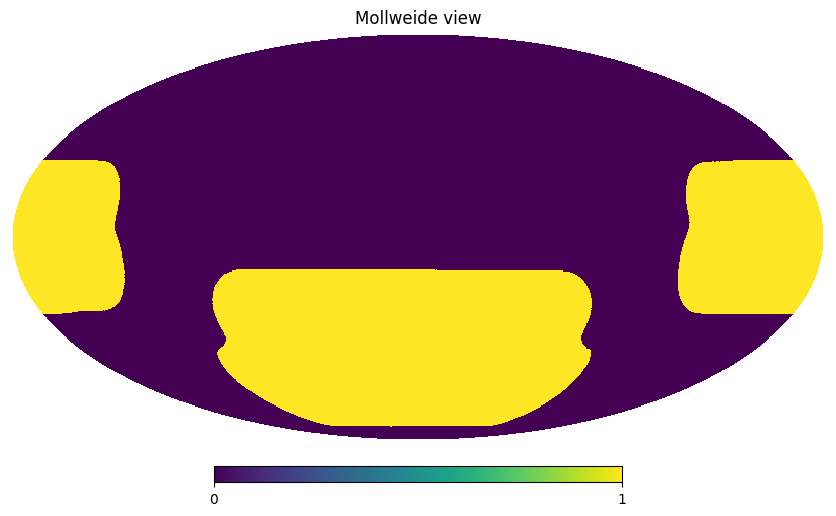

In [5]:
wsa = hp.ud_grade(hp.fitsfunc.read_map(fmasksa,verbose=False),512)
#r = hp.rotator.Rotator(coord=['G','C'])
#wsa = hp.rotator.Rotator.rotate_map_pixel(r,Wsa)
msa = wsa/(wsa+1e-30)
hp.mollview(msa)

**Falta hacer los hit count del paper de SO del 2022, que supongo que deben ser como la multiplicacion entre las mascaras que obtuve con el hitmaps de antes, con el detalle de que habria que promediar todos los hitmaps de cada frecuencia no?? o algo asi ya que tenemos varios tubos que representan una cierta frecuencia.**

- Tambien falta hacer la mascara de SAT con la apodizacion correspondiente (creo)